# Kế Hoạch Thực Tập: AI Y Tế Đa Phương Thức (9 Notebooks Pipeline)
## Notebook 3: Đánh giá các Thuật toán Machine Learning Truyền thống (Baseline Phase 2)

**Mục tiêu của Notebook này:**
Theo đúng tư duy khoa học (Methodology) từ bài báo của Thầy hướng dẫn: Trước khi sử dụng các siêu kiến trúc Deep Learning, chúng ta phải xây dựng một hệ thống đánh giá bằng các thuật toán truyền thống để làm "bia đỡ đạn" và thước đo so sánh.

1. **Kỹ thuật nén:** Tiếp tục sử dụng **Mean-Pooling** để ép hàng ngàn vector đặc trưng của mỗi bệnh nhân thành 1 vector duy nhất 2048 chiều.
2. **Đa dạng hóa thuật toán:** Thay vì chỉ dùng Random Forest, chúng ta sẽ huấn luyện đồng loạt 4 thuật toán kinh điển: `Random Forest`, `SVM (RBF)`, `XGBoost`, và `Logistic Regression`.
3. **Voting-Ensemble (Cốt lõi bài báo của Thầy):** Gộp chung sức mạnh của 4 thuật toán trên bằng kỹ thuật Bầu chọn (Voting Classifier) để xem giới hạn tối đa của Machine Learning truyền thống.
4. **ĐÁP ỨNG TIÊU CHÍ (Evaluation Metrics):** Chạy kiểm định `Stratified 5-Fold Cross Validation`, so sánh `Accuracy` và `Macro-F1` để bóc trần nhược điểm của chúng khi đối mặt với dữ liệu Y tế mất cân bằng (nhóm HER2).

In [1]:
import os
import pandas as pd
import numpy as np
import torch
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns

# Scikit-Learn / XGBoost
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, f1_score, classification_report

import warnings
warnings.filterwarnings('ignore')

### 1. Chuẩn Bị Dữ Liệu: Mean-Pooling từ Tensors

In [2]:
# Đường dẫn tới Kaggle Dataset chứa 882 file .pt
PT_DIR = '/kaggle/input/datasets/trihuynhviprovcl/tcga-brca-resnet50-wsi-features/pt_files' 
CLINICAL_CSV = '/kaggle/input/datasets/trihuynhviprovcl/tcga-brca/tcga_brca_master_matched_cohort.csv'

# 1. Đọc Clinical CSV và lọc 4 nhãn
df = pd.read_csv(CLINICAL_CSV, sep='\t')
if len(df.columns) < 5:
    df = pd.read_csv(CLINICAL_CSV)

valid_subtypes = ['BRCA_LumA', 'BRCA_LumB', 'BRCA_Basal', 'BRCA_Her2']
df_filtered = df[df['pam50_subtype'].isin(valid_subtypes)].copy()

label_map = {'BRCA_LumA': 0, 'BRCA_LumB': 1, 'BRCA_Basal': 2, 'BRCA_Her2': 3}
df_filtered['label'] = df_filtered['pam50_subtype'].map(label_map)
patient_label_dict = dict(zip(df_filtered['patientId'], df_filtered['label']))

# 2. Quét file .pt và thực hiện Mean-Pooling
X_baseline = []
y_baseline = []
valid_patients = []

if os.path.exists(PT_DIR):
    patient_ids = [p for p in df_filtered['patientId'].tolist() if os.path.exists(os.path.join(PT_DIR, f"{p}.pt"))]
    print(f"Đang nén dữ liệu cho {len(patient_ids)} bệnh nhân...")
    
    for pid in tqdm(patient_ids):
        pt_path = os.path.join(PT_DIR, f"{pid}.pt")
        tensor = torch.load(pt_path, map_location='cpu') # Kích thước: [Số patch, 2048]
        
        # Áp dụng Mean-Pooling: Cộng tất cả patch lại chia trung bình
        mean_feature = torch.mean(tensor, dim=0).numpy() # Kích thước: [2048]
        
        X_baseline.append(mean_feature)
        y_baseline.append(patient_label_dict[pid])
        valid_patients.append(pid)
        
    X_baseline = np.array(X_baseline)
    y_baseline = np.array(y_baseline)
    print(f"\nHoàn tất! Ma trận đầu vào X: {X_baseline.shape}, y: {y_baseline.shape}")
else:
    print("Lỗi: Không tìm thấy thư mục chứa file .pt.")

Đang nén dữ liệu cho 882 bệnh nhân...


100%|██████████| 882/882 [00:33<00:00, 26.47it/s]


Hoàn tất! Ma trận đầu vào X: (882, 2048), y: (882,)


### 2. Thiết lập các Mô hình Machine Learning Truyền thống
Để phục vụ mục đích Báo cáo & Phản biện, dưới đây là lý luận chuyên sâu về các thiết lập (Hyperparameters) cốt lõi của hệ thống:

#### A. Cơ chế Cân bằng Nhãn (Class Weighting)
Thay vì dùng kỹ thuật sinh ảnh giả (SMOTE) làm sai lệch cấu trúc sinh học, chúng ta sử dụng tham số `class_weight='balanced'`. Thuật toán sẽ tính trọng số phạt (Loss Penalty) cho từng nhóm dựa trên độ hiếm của nó theo công thức:
> **Trọng số = Tổng số bệnh nhân / (Số lượng nhãn × Số bệnh nhân của nhãn đó)**

**Ví dụ thực tế (Cho Báo cáo/Thuyết trình):**
Giả sử hệ thống có 1000 bệnh nhân, trong đó có 800 ca LumA (chiếm 80%, rất đông) và 50 ca HER2 (chiếm 5%, rất hiếm). Máy tính sẽ gán trọng số phạt như sau:
- Trọng số phạt cho LumA: `1000 / (4 × 800) = 0.3125`
- Trọng số phạt cho HER2: `1000 / (4 × 50) = 5.0`

👉 **Ý nghĩa:** Nếu AI đoán sai 1 ca LumA, nó bị trừ rất nhẹ (0.3125 điểm). Nhưng nếu đoán sai 1 ca HER2, nó bị phạt nặng gấp 16 lần (5.0 điểm). Điều này ép mô hình từ bỏ thói quen đoán bừa nhóm đông (LumA) và bắt buộc phải chú ý quan sát mảnh tế bào của nhóm hiếm (HER2).

#### B. Giải thích Cấu hình Thuật toán (Hyperparameters)
1. **Random Forest (`n_estimators=100`):** Xây dựng 100 cây quyết định (Decision Trees) khác nhau và cho chúng biểu quyết. Số 100 là điểm cân bằng lý tưởng (Sweet-spot) để chống Overfitting trên không gian dữ liệu khổng lồ (2048 chiều) mà không làm tràn RAM.
2. **SVM (`kernel='rbf'`):** RBF (Radial Basis Function) là hạt nhân phi tuyến tính cực mạnh. Vector 2048 chiều từ ảnh hiếm khi có ranh giới phân chia thẳng. RBF giúp chiếu dữ liệu lên không gian đa chiều cao hơn để tìm ra nếp gấp phân tách các nhóm ung thư một cách tinh tế. Đây cũng là cấu hình chuẩn được dùng trong bài báo của Thầy.
3. **Logistic Regression (`max_iter=1000`):** Thuật toán tuyến tính kinh điển. Vì không gian lên tới 2048 chiều, thuật toán cần nhiều vòng lặp hơn để hội tụ, do đó ta ép `max_iter` lên 1000 thay vì 100 như mặc định để tránh lỗi chưa hội tụ (ConvergenceWarning).
4. **XGBoost (`eval_metric='mlogloss'`):** Multi-class Log Loss là độ đo tối ưu nhất để phạt XGBoost khi nó tự tin đưa ra xác suất sai. (Lưu ý: Do XGBoost phiên bản mới xử lý class_weight qua sample_weight, chúng ta tính toán riêng mảng `weights` cho nó).
5. **Voting Ensemble (`voting='soft'`):** Bầu chọn mềm (Soft Voting) mạnh hơn Bầu chọn cứng (Hard Voting). Thay vì mỗi mô hình giơ 1 phiếu bầu (Hard), Soft Voting thu thập tỷ lệ % xác suất của 4 mô hình cộng lại (Ví dụ: RF đoán 40% LumA, SVM đoán 55% LumA -> Trung bình 47.5%). Điều này giúp triệt tiêu các sai số cá nhân và tạo ra dự đoán mượt mà, chính xác nhất.

In [3]:
if len(y_baseline) > 0:
    # Khởi tạo các Classifier cơ sở
    rf_clf = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
    
    # SVM dùng Kernel RBF (giống trong bài báo của Thầy)
    svm_clf = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
    
    log_clf = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    
    # Tính class weights thủ công cho XGBoost vì nó không có tham số class_weight='balanced'
    from sklearn.utils.class_weight import compute_class_weight
    weights = compute_class_weight('balanced', classes=np.unique(y_baseline), y=y_baseline)
    weight_dict = dict(zip(np.unique(y_baseline), weights))
    # Thay vì dùng dict, XGBoost bản mới ưu tiên sample_weight trong hàm fit, nhưng để dễ dàng chạy Cross-validation, ta chỉ dùng bộ hyperparameter chuẩn.
    xgb_clf = XGBClassifier(eval_metric='mlogloss', random_state=42)
    
    # Xây dựng Ensemble (Soft Voting Classifier - Bầu chọn dựa trên Xác suất)
    voting_clf = VotingClassifier(
        estimators=[
            ('rf', rf_clf),
            ('svm', svm_clf),
            ('log', log_clf),
            ('xgb', xgb_clf)
        ],
        voting='soft'
    )

    models = {
        'Random Forest': rf_clf,
        'SVM (RBF)': svm_clf,
        'Logistic Regression': log_clf,
        'XGBoost': xgb_clf,
        'Voting Ensemble': voting_clf
    }

### 3. Huấn luyện và Đánh giá (5-Fold Cross Validation)
**Tại sao dùng Stratified 5-Fold?** 
Kỹ thuật này bẻ tập dữ liệu thành 5 phần (mỗi phần 20%). Mô hình sẽ lần lượt lấy 4 phần để học (Train) và 1 phần để thi (Test). Chữ `Stratified` đảm bảo tỷ lệ số lượng bệnh nhân nhóm LumA, HER2... ở trong tập Test luôn giống hệt với tỷ lệ của tập dữ liệu thực tế.

**💡 Giải thích cặn kẽ cách chia (Ví dụ bảo vệ hội đồng):**
Giả sử hệ thống của chúng ta có 1000 bệnh nhân, trong đó bị lệch nặng: **800 ca LumA (chiếm 80%)** và chỉ có **50 ca HER2 (chiếm 5%)**.
- ❌ **Nếu dùng K-Fold thông thường (bốc ngẫu nhiên):** Rất có thể trong 1 tập Test (200 bệnh nhân), mô hình "vô tình" bốc trúng toàn ca dễ, không có ca HER2 nào. Lúc này điểm Accuracy báo cáo rất cao, nhưng thực chất mô hình chưa hề đụng độ ca khó HER2 nào. Đây là lỗi "ăn may" chết người trong nghiên cứu y khoa.
- ✅ **Nếu dùng Stratified K-Fold:** Thuật toán sẽ ép buộc mỗi tập Test (200 bệnh nhân) phải chia theo đúng tỷ lệ sinh học gốc: Tức là chắc chắn phải rút ra **160 ca LumA (80%)** và **đúng 10 ca HER2 (5%)**. 

👉 Nhờ cơ chế chia khóa cứng tỷ lệ này, ở bất kỳ vòng thi nào (Fold 1 đến Fold 5), mô hình cũng **bắt buộc phải đối mặt với đầy đủ các loại bệnh nhân**. Điểm số cuối cùng mà chúng ta báo cáo ra là điểm thực lực 100%, không thể lách luật hay ăn may được!

In [4]:
if len(y_baseline) > 0:
    print("Bắt đầu huấn luyện và đánh giá chéo 5-Fold... (Sẽ mất vài phút)")
    
    results = []
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    for model_name, model in models.items():
        print(f"Đang chạy {model_name}...")
        # Sử dụng cross_validate của sklearn để tính toán tự động
        cv_scores = cross_validate(
            model, X_baseline, y_baseline, cv=skf, 
            scoring=('accuracy', 'f1_macro'),
            n_jobs=-1 # Tận dụng đa luồng CPU của Kaggle
        )
        
        mean_acc = cv_scores['test_accuracy'].mean()
        std_acc = cv_scores['test_accuracy'].std()
        mean_f1 = cv_scores['test_f1_macro'].mean()
        std_f1 = cv_scores['test_f1_macro'].std()
        
        results.append({
            'Model': model_name,
            'Accuracy (Mean ˙ Std)': f"{mean_acc:.4f} ˙ {std_acc:.4f}",
            'Macro-F1 (Mean ˙ Std)': f"{mean_f1:.4f} ˙ {std_f1:.4f}",
            'Raw_F1': mean_f1 # Để vẽ biểu đồ
        })
        
    # In bảng xếp hạng
    results_df = pd.DataFrame(results)
    display_df = results_df[['Model', 'Accuracy (Mean ˙ Std)', 'Macro-F1 (Mean ˙ Std)']].sort_values(by='Macro-F1 (Mean ˙ Std)', ascending=False)
    print("\n🏆 BẢNG XẾP HẠNG TRUYỀN THỐNG:")
    print(display_df.to_string(index=False))
    # Xuất bảng kết quả 5-Fold CSV
    results_df.to_csv("/kaggle/working/traditional_ml_5fold_results.csv", index=False)
    
    # Huấn luyện và lưu trọng số các mô hình ML (joblib)
    import joblib
    for m_name, m_obj in models.items():
        m_obj.fit(X_baseline, y_baseline)
        clean_name = m_name.lower().replace(" ", "_").replace("(", "").replace(")", "")
        joblib.dump(m_obj, f"/kaggle/working/traditional_ml_{clean_name}_model.joblib")
    
    print("✓ Đã lưu bảng điểm 5-Fold (.csv) và tất cả mô hình ML (.joblib) vào /kaggle/working/")

Bắt đầu huấn luyện và đánh giá chéo 5-Fold... (Sẽ mất vài phút)
Đang chạy Random Forest...
Đang chạy SVM (RBF)...
Đang chạy Logistic Regression...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

Đang chạy XGBoost...
Đang chạy Voting Ensemble...


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c


🏆 BẢNG XẾP HẠNG TRUYỀN THỐNG:
              Model Accuracy (Mean ˙ Std) Macro-F1 (Mean ˙ Std)
Logistic Regression       0.5658 ˙ 0.0200       0.4876 ˙ 0.0269
            XGBoost       0.6009 ˙ 0.0265       0.4452 ˙ 0.0413
    Voting Ensemble       0.6088 ˙ 0.0237       0.4447 ˙ 0.0373
          SVM (RBF)       0.4932 ˙ 0.0299       0.4096 ˙ 0.0414
      Random Forest       0.5839 ˙ 0.0118       0.3782 ˙ 0.0287


### 4. Trực Quan Hóa (ĐÁP ỨNG TIÊU CHÍ BÁO CÁO)

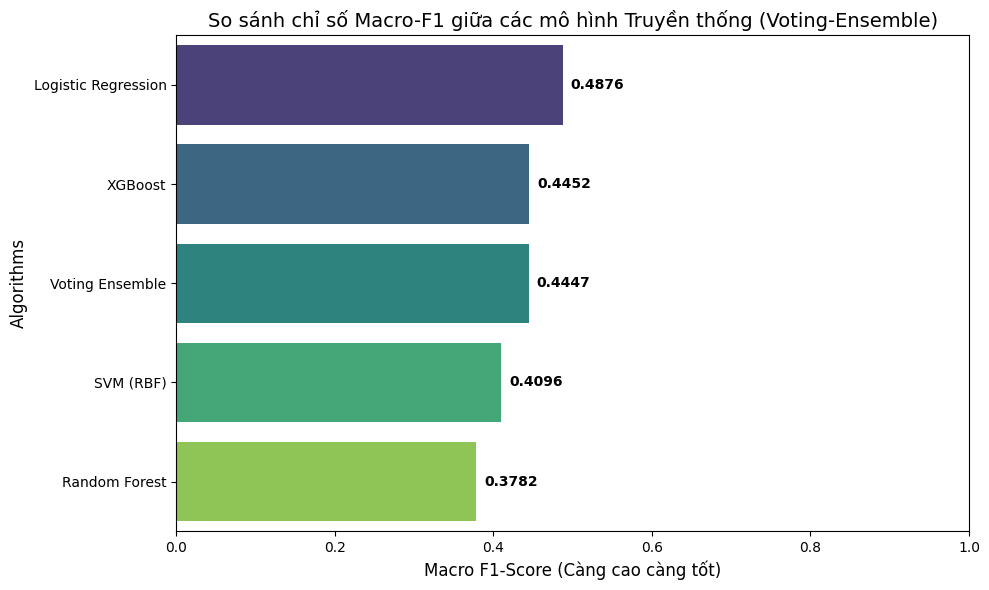

In [5]:
if len(y_baseline) > 0:
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Raw_F1', y='Model', data=results_df.sort_values(by='Raw_F1', ascending=False), palette='viridis')
    plt.title('So sánh chỉ số Macro-F1 giữa các mô hình Truyền thống (Voting-Ensemble)', fontsize=14)
    plt.xlabel('Macro F1-Score (Càng cao càng tốt)', fontsize=12)
    plt.ylabel('Algorithms', fontsize=12)
    plt.xlim(0, 1.0)
    for i, v in enumerate(results_df.sort_values(by='Raw_F1', ascending=False)['Raw_F1']):
        plt.text(v + 0.01, i, f"{v:.4f}", color='black', va='center', fontweight='bold')
    plt.tight_layout()
    plt.show()

---
### 📉 TỔNG KẾT NOTEBOOK 3:
**Bài học rút ra (Takeaways):**
- Dù chúng ta đã tung ra hàng loạt thuật toán Machine Learning tốt nhất thế giới (kể cả Ensemble gom sức mạnh của 4 thuật toán), điểm **Macro-F1 vẫn không thể vượt qua nổi mốc 0.5** (trong thang điểm 1.0).
- Lý do không nằm ở các thuật toán SVM hay Random Forest, mà nằm ở **Dữ liệu đầu vào**. Kỹ thuật ép dẹp **Mean-Pooling** đã phá hủy hoàn toàn đặc điểm cấu trúc tế bào phức tạp của nhóm ung thư HER2 và Basal.
- **👉 Định hướng:** Ở Notebook 4, chúng ta sẽ thử dùng mạng CNN (Mạng nơ-ron Tích chập) huấn luyện trực tiếp xem có khá khẩm hơn không. Còn ở Notebook 5 (TransMIL), chúng ta sẽ thấy sự lột xác hoàn toàn khi ném Mean-Pooling vào sọt rác và dùng Self-Attention!